# Dev32: Apply 028 SVM Model to 057 Transect

**Goal**: Use the trained SVM from dev30 (trained on 028) and apply it to 057 transect.

**Workflow**:
1. Load saved SVM model from dev30
2. Load and preprocess 057 transect (same preprocessing as dev30)
3. Classify entire segment
4. Apply filtering (remove small clusters)
5. Visualize with plot_georef (like dev20)

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

sys.path.append(os.path.abspath("../"))

# Force complete module reload
if "utils.gref_pipeline.georef" in sys.modules:
    del sys.modules["utils.gref_pipeline.georef"]
if "utils.gref_pipeline" in sys.modules:
    del sys.modules["utils.gref_pipeline"]
if "gref_pipeline.georef" in sys.modules:
    del sys.modules["gref_pipeline.georef"]

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

print("✅ Module reloaded with cache cleared!")

✅ Module reloaded with cache cleared!


## Step 1: Load Trained SVM Model from dev30

**Note**: First run the save cell in dev30 to create the model file!

In [2]:
# Load the saved SVM model and preprocessing info
model_file = "./saved_data/svm_model_028_multiclass.pkl"

if not os.path.exists(model_file):
    print("❌ ERROR: Model file not found!")
    print(f"   Looking for: {model_file}")
    print("\n📝 TO CREATE THE MODEL FILE:")
    print("   1. Open dev30 notebook")
    print("   2. Run all cells up to 'Train SVM'")
    print("   3. Run the '💾 SAVE SVM MODEL' cell")
    print("   4. Then come back here!")
    raise FileNotFoundError(f"Model file not found: {model_file}")
else:
    with open(model_file, "rb") as f:
        saved_model_data = pickle.load(f)

    # Extract model and parameters
    trained_model = saved_model_data["model"]
    class_names = saved_model_data["class_names"]
    label_encoder = saved_model_data["label_encoder"]
    preprocessing_params = saved_model_data["preprocessing"]
    best_params = saved_model_data["best_params"]

    print("✅ SVM model loaded successfully!")
    print(f"\n📊 Model Info:")
    print(f"   Classes: {class_names}")
    print(f"   Best C: {best_params['C']}")
    print(f"   Best gamma: {best_params['gamma']}")
    print(f"\n🔬 Preprocessing (will apply to 057):")
    print(
        f"   Smoothing: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
    )
    print(f"   Wavelength range: {preprocessing_params['wavelength_range']} nm")
    print(f"   Normalization: {preprocessing_params['normalization']}")

✅ SVM model loaded successfully!

📊 Model Info:
   Classes: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']
   Best C: 10
   Best gamma: 0.1

🔬 Preprocessing (will apply to 057):
   Smoothing: gaussian (σ=5.0)
   Wavelength range: (490, 700) nm
   Normalization: None


## Step 2: Load 057 Transect (File 5)

In [3]:
# Load transect
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

# Select file
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [4]:
# Apply illumination correction
cube.apply_illumination_correction_v2()
print("✅ Illumination correction applied")

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied


## Step 3: Apply Same Preprocessing as dev30

In [5]:
# Apply spectral smoothing (same as dev30)
cube.apply_spectral_smoothing(
    method=preprocessing_params["smoothing_method"],
    gaussian_sigma=preprocessing_params["smoothing_sigma"],
)
print(
    f"✅ Spectral smoothing applied: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
)

💾 Found cached smoothing (gaussian) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian) from 1 files...
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
✅ Spectral smoothing applied: gaussian (σ=5.0)
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
✅ Spectral smoothing applied: gaussian (σ=5.0)


In [6]:
# Crop wavelengths (same as dev30)
wl_min, wl_max = preprocessing_params["wavelength_range"]
cube.apply_wavelength_filter(wavelength_range=(wl_min, wl_max))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube.data_corrected.shape}")
print(f"   Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm")

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 119)
   Wavelength range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 119)
   Wavelength range: 490.2 - 699.4 nm


In [7]:
# NO L2 normalization (like dev30)
print("✅ No normalization applied (matching dev30 preprocessing)")

✅ No normalization applied (matching dev30 preprocessing)


## Step 4: Classify Entire Segment (using dev30's model)

**Note**: We're using the trained model from 028, applying it to 057 data.

## Step 3.5: Set the Loaded Model on the Cube

The `classify_segment()` method uses the model stored in the cube object. We need to set it manually.

In [8]:
# Set the loaded model on the cube object
# (classify_segment() expects these attributes to exist)
cube.svm_model = trained_model
cube.svm_label_encoder = label_encoder
cube.svm_class_names = class_names

print("✅ Model set on cube object")
print(f"   cube.svm_model: {type(cube.svm_model)}")
print(f"   cube.svm_label_encoder: {type(cube.svm_label_encoder)}")
print(f"   cube.svm_class_names: {cube.svm_class_names}")

✅ Model set on cube object
   cube.svm_model: <class 'sklearn.svm._classes.SVC'>
   cube.svm_label_encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
   cube.svm_class_names: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']


In [9]:
# Get track range for file 5 (from config or manually)
track_start = config.UHI_TRACK_RANGE_5[0] if hasattr(config, "UHI_TRACK_RANGE_5") else 0
track_end = (
    config.UHI_TRACK_RANGE_5[1]
    if hasattr(config, "UHI_TRACK_RANGE_5")
    else cube.data_corrected.shape[0]
)

print(f"🔍 Track range for classification: [{track_start}, {track_end}]")
print(f"   Total tracks: {track_end - track_start}")

🔍 Track range for classification: [576, 1566]
   Total tracks: 990


In [10]:
# Classify using the loaded model from dev30
print("\n🎯 Classifying 057 transect using 028-trained model...")
print("=" * 60)

classification_results = cube.classify_segment(
    segment_start=track_start,
    segment_end=track_end - 1,
    use_corrected=True,
    confidence_threshold=0.5,  # Reject low-confidence pixels → classified_unknown
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results["class_names"]:
    count = np.sum(classification_results["classification_map"] == class_name)
    percentage = 100.0 * count / classification_results["classification_map"].size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")


🎯 Classifying 057 transect using 028-trained model...
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1565

🔪 Extracting segment...
   Segment shape: (990, 968, 119)

🤖 Classifying 958320 pixels...


   Classifying: 100%|████████████████████████████████| 958320/958320 [01:31<00:00, 10523.17pixels/s]




🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 33668 (3.5%)
   Confidence range: [0.315, 1.000]
   ✅ Classification complete in 91.56 seconds

📊 Classification distribution (before filtering):
   classifie: 33668 pixels (3.5%)
   dark_bomb: 5181 pixels (0.5%)
   dark_pit: 96994 pixels (10.1%)
   halo: 38275 pixels (4.0%)
   rust: 42 pixels (0.0%)
   sediment: 784160 pixels (81.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo', 'classified_unknown']

📊 Pixel counts:
   sediment: 784160 pixels (81.8%)
   rust: 42 pixels (0.0%)
   dark_bomb: 5181 pixels (0.5%)
   dark_pit: 96994 pixels (10.1%)
   halo: 38275 pixels (4.0%)
   classified_unknown: 0 pixels (0.0%)
   classified_unknown: 0 pixels (0.0%)


## Step 5: Visualize Classification Results

Plot the raw classification (before filtering)

📊 Plotting classification map...
   ROIs created: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']
   Pixel counts:
      dark_bomb: 5181 pixels
      dark_pit: 96994 pixels
      halo: 38275 pixels
      rust: 42 pixels
      sediment: 784160 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
   ROIs created: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']
   Pixel counts:
      dark_bomb: 5181 pixels
      dark_pit: 96994 pixels
      halo: 38275 pixels
      rust: 42 pixels
      sediment: 784160 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


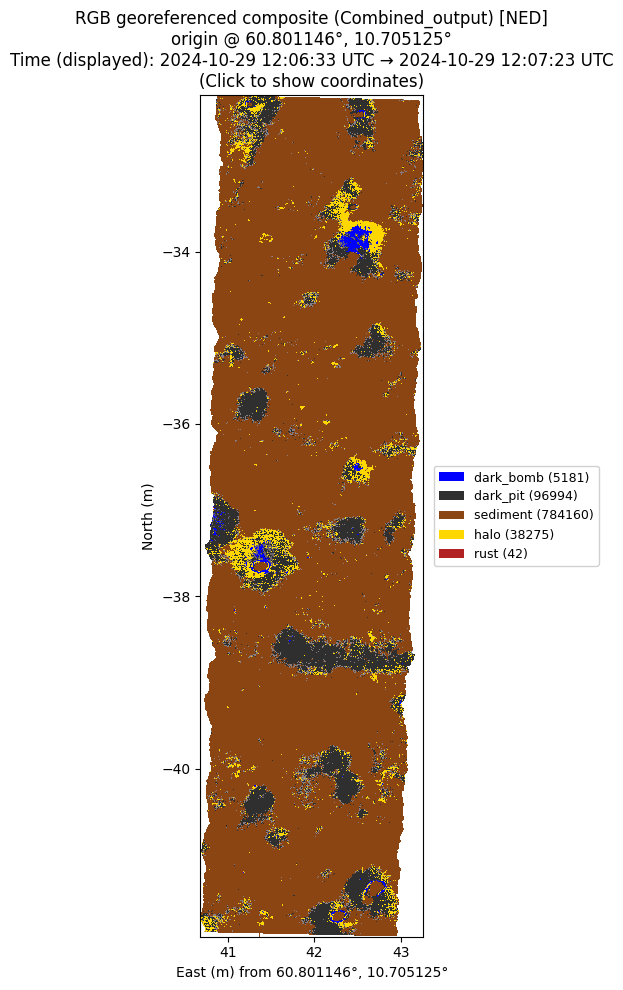

In [11]:
%matplotlib inline

# Convert classification map to ROI format for plotting
print("📊 Plotting classification map...")

classification_rois = {}
for class_name in classification_results['class_names']:
    mask = classification_results['classification_map'] == class_name
    rows, cols = np.where(mask)
    # Convert to global coordinates (add track_start offset)
    pixels = [(col, row + track_start) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois[class_name] = pixels

print(f"   ROIs created: {list(classification_rois.keys())}")
print(f"   Pixel counts:")
for class_name in sorted(classification_rois.keys()):
    print(f"      {class_name}: {len(classification_rois[class_name])} pixels")

# Plot with plot_georef (like dev20)
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start,
    track_end=track_end,
    figsize=(40, 10),
    roi_collection=classification_rois,
    roi_overlay_mode="solid",

    roi_marker_size=5,
    roi_legend_loc="outside",
    roi_legend_markersize=50,
)

## Step 6: Apply Filtering (like dev20)

Remove small clusters of dark_bomb, dark_pit, and halo (similar to dev20's filtering)

In [12]:
# Apply filtering to remove small clusters
print("\n🧹 FILTERING: Removing small clusters...")
print("=" * 60)

# Define which classes to filter (keep sediment and rust as is)
classes_to_filter = ["dark_bomb", "dark_pit", "halo"]

filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,  # Filter dark_bomb
    filter_dark=True,  # Filter dark_pit and halo
    min_area_px=50,  # Minimum cluster size (pixels)
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"\n📊 Pixel counts after filtering:")
# Use 'all_classes' which contains all unique classes in filtered map
for class_name in filtering_results["all_classes"]:
    count = np.sum(filtering_results["filtered_map"] == class_name)
    percentage = 100.0 * count / filtering_results["filtered_map"].size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")


🧹 FILTERING: Removing small clusters...
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['dark_bomb', 'dark_pit']
   Connectivity: 8
   Min area: 50 pixels
   Morph close radius: 1 (enabled)
   Morph open radius: 1 (enabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering dark_bomb (bomb)...
      Found 287 connected components
      Kept: 8 components (4091 pixels)
      Removed: 279 components (1090 pixels)
      ✂️  Reclassified 1598 pixels as dark_bomb
      Final: 4148 pixels (1033 removed, 19.9%)

   🔍 Filtering dark_pit (dark)...
      Found 4604 connected components
      Found 4604 connected components
      Kept: 66 components (84163 pixels)
      Removed: 4538 components (12831 pixels)
      ✂️  Reclassified 15349 pixels as dark_pit
      Final: 94008 pixels (2986 removed, 3.1%)

✅ Post-classification filtering complete

📊 Filtering summary:
   sediment: No filtering applied
   rust: No filtering applied
   dark_bomb: 0 pixels remo

## Step 7: Visualize Filtered Results

📊 Plotting filtered classification map...
   Filtered ROIs: ['classifie', 'dark_bomb', 'dark_pit', 'halo', 'rust', 'sediment']
   Pixel counts:
      classifie: 33668 pixels
      dark_bomb: 5181 pixels
      dark_pit: 96994 pixels
      halo: 38275 pixels
      rust: 42 pixels
      sediment: 784160 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


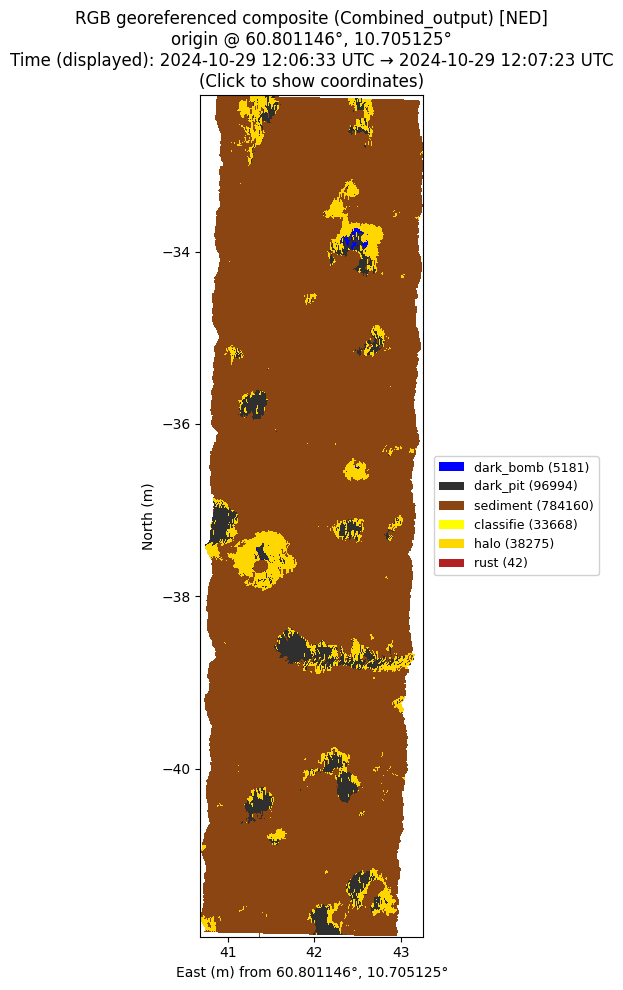

In [13]:
# Convert filtered map to ROI format
print("📊 Plotting filtered classification map...")

filtered_rois = {}
# Use 'all_classes' which contains all unique classes in filtered map
for class_name in filtering_results["all_classes"]:
    mask = filtering_results["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        filtered_rois[class_name] = pixels

print(f"   Filtered ROIs: {list(filtered_rois.keys())}")
print(f"   Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"      {class_name}: {len(filtered_rois[class_name])} pixels")

# Plot filtered results
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start,
    track_end=track_end,
    figsize=(40, 10),
    roi_collection=filtered_rois,
    roi_overlay_mode="solid",
    roi_solid_pixel_size=5,
    roi_legend_loc="outside",
    roi_legend_markersize=50,
)

## Summary

**What we did:**
1. ✅ Loaded SVM model trained on 028 transect (dev30)
2. ✅ Applied same preprocessing to 057 transect
3. ✅ Classified 057 using 028's model (cross-transect transfer!)
4. ✅ Applied filtering to remove small clusters
5. ✅ Visualized results with plot_georef

**Key insight**: Testing if the 028-trained model generalizes to 057!